# Introduction

Stock price prediction is an obvious application for data analysis and modelling. Having an accurate idea as to the price of a given stock at any point informs the buyer as to whether or not a purchase of that stock at the time is advisable. Furthermore, modelling might well allow for predictions in future trends of the price of the stock, allowing one to make much more informed decisions regarding their investment portfolio. The most popular methods of modelling stock prices tend to involve deep learning models such as LSTM (long short-term memory) and machine learning. This notebook will attempt to build a model based on a "hybrid" approach that can then be used to predict the closing stock price of a given company; Apple Inc. (stock symbol AAPL) has been used as an example for the notebook only.

# Modelling Approach

The modelling approach used will combine three principle models to predict future stock prices; ARIMA, GARCH and Ridge Regression.

## ARIMA

ARIMA (AutoRegressive Integrated Moving Average): A time series forecasting method that is particularly suited for univariate data, i.e. a single time-dependent variable like stock prices. It is characterized by three main components:
  
- AR (Autoregressive): This part of the model uses the dependency between and observation and a number of lagged observations. It expresses the current values as a linear combination of its past values.
- I (Integrated): This part of the model is used to make the time series stationary (so that its statistical properties, such as mean and variance, remain constant over time). This is achieved through differencing, which substracts the current value from the previous one.
- MA (Moving Average): This part of the model is responsible for modelling the relationship between an observation and a residual error from a moving average model applied to lagged observations.

In this case, ARIMA is applied to the log returns of the stock price to capture patterns and trends. The residuals from ARIMA represent the part of the stock return that ARIMA has not captured. These residuals are then used in the next step as features for the GARCH model.

## GARCH

GARCH (or Generalized Autoregressive Conditional Heteroskedasticity) is a model used to estimate the volatility (uncertainty) of time series data, especially in financial markets. In finance, volatility measures the variability of returns over time and is often seen as a proxy for risk. The GARCH modedl is designed to capture time-varying volatility, common in financial data. GARCH models assume that volatility is not constant, but changes over time, depending on past errors and variances.

In this case, GARCH is applied to the residuals from the ARIMA model to capture the time-varying volatility (uncertainty) of stock returns. The GARCH model forecasts theh volatilitty for the next 365 days, which is then used as a feature in the Ridge Regression model.

## Ridge Regression (Meta-Model)

Ridge Regression is a linear regression model that includes a regularization term (L2) to prevent overfitting. In ordinary linear regression, the model seeks to minimize the sum of squared residuals (difference between the predicted and actual values). In Ridge Regression, a penalty is added to the cost function based on the magnitude of the coefficients. The purpose of the penalty is to shrink the coefficients, preventing overfitting and improving the model's generalization on unseen data.

After the ARIMA and GARCH models generate residuals and volatility, these outputs are used as features and passed to the Ridge Regression model. The model predicts the future stock prices using these features.

In short, the modelling approach used may be summarized as follows:
- ARIMA captures the trends and generates residuals from the stock returns.
- GARCH models the volatility of stock returns, based on the residuals from the ARIMA model.
- Ridge Regression is used as the meta-model to predict future stock prices based on the ARIMA residuals and GARCH volatility.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


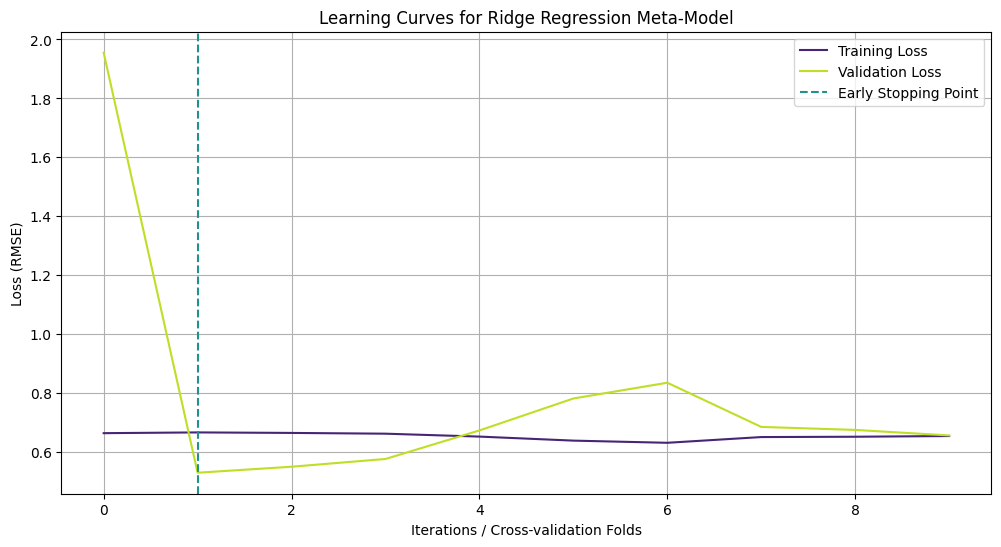

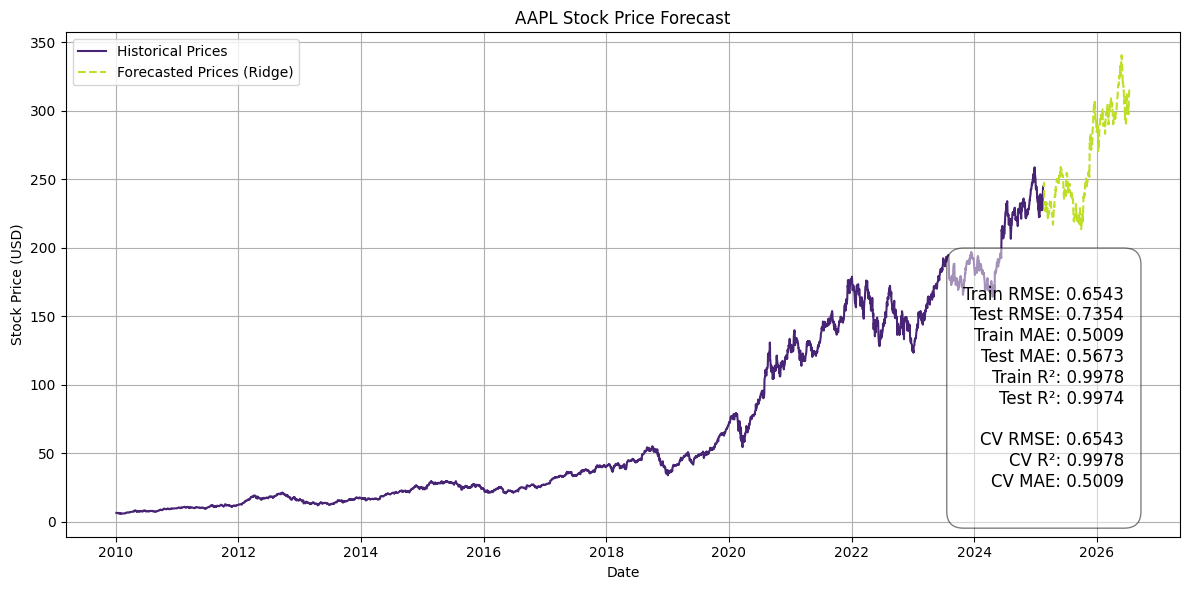

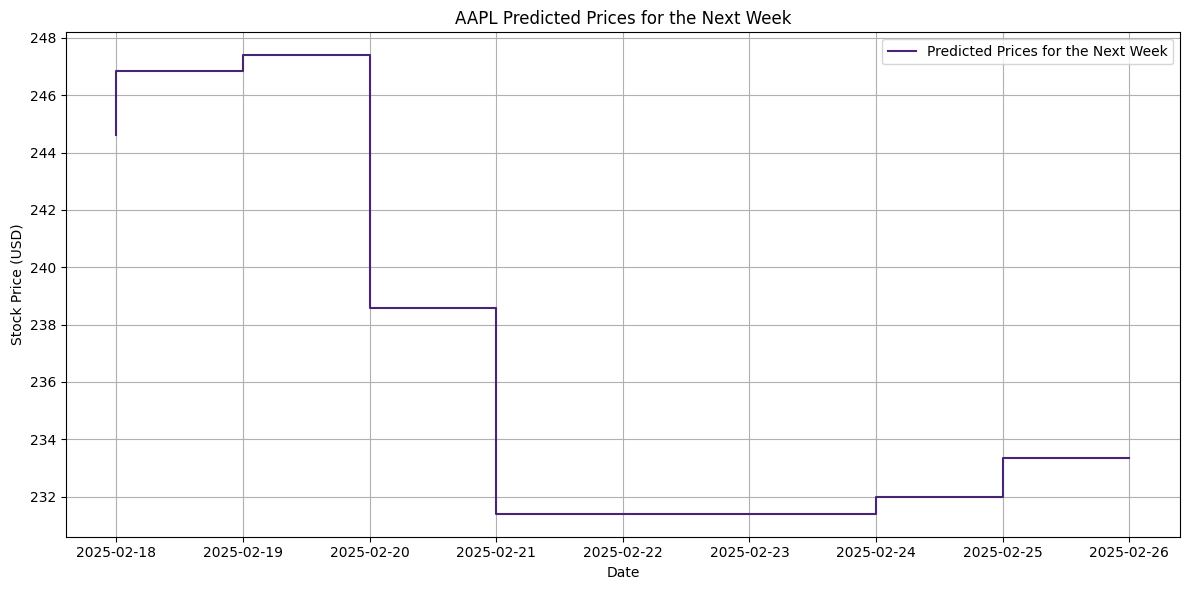

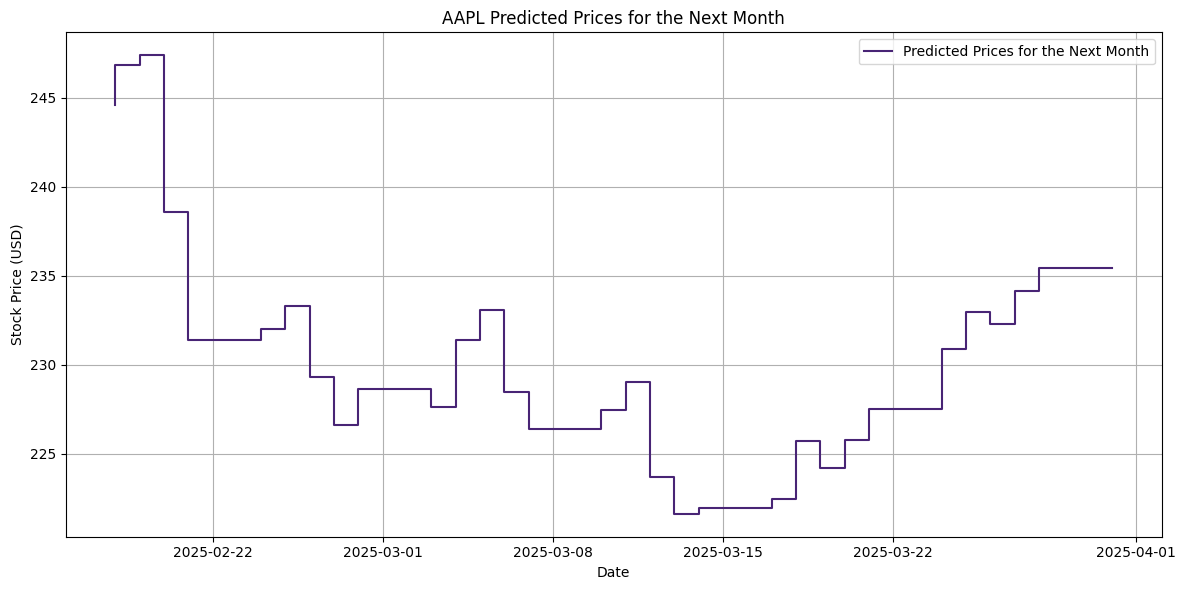

In [51]:
import datetime
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings("ignore")

# Download stock data
stock_symbol = 'AAPL'
data = yf.download(stock_symbol, start='2010-01-01', end=datetime.date.today().strftime('%Y-%m-%d'))
data['Log_Ret'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()

# Fit ARIMA model to the log returns
log_returns = data['Log_Ret']
arima_model = ARIMA(log_returns, order=(5, 0, 0))
arima_result = arima_model.fit()

# ARIMA Residuals
arima_residuals = arima_result.resid

# Fit GARCH model to the residuals of the ARIMA model
garch_model = arch_model(arima_residuals, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

# Forecast GARCH volatility for the next 365 days
garch_forecast = garch_result.forecast(horizon=365)
garch_volatility = np.sqrt(garch_forecast.variance.iloc[-1]).values

# Prepare features for Ridge Regression (ARIMA residuals and GARCH volatility)
features = pd.DataFrame({
    'ARIMA_Residuals': arima_residuals[-365:],  # Last 365 residuals
    'GARCH_Volatility': garch_volatility
})

target = log_returns[-365:] * 1000  # Scale target to match the length of features
features = features[np.isfinite(target)]
target = target[np.isfinite(target)]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, shuffle=False)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Suppress warnings
warnings.filterwarnings("ignore")

# Download stock data
stock_symbol = 'AAPL'
data = yf.download(stock_symbol, start='2010-01-01', end=datetime.date.today().strftime('%Y-%m-%d'))
data['Log_Ret'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()

# Fit ARIMA model to the log returns
log_returns = data['Log_Ret']
arima_model = ARIMA(log_returns, order=(5, 0, 0))
arima_result = arima_model.fit()

# ARIMA Residuals
arima_residuals = arima_result.resid

# Fit GARCH model to the residuals of the ARIMA model
garch_model = arch_model(arima_residuals, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

# Forecast GARCH volatility for the next 365 days
garch_forecast = garch_result.forecast(horizon=365)
garch_volatility = np.sqrt(garch_forecast.variance.iloc[-1]).values

# Prepare features for Ridge Regression (ARIMA residuals and GARCH volatility)
features = pd.DataFrame({
    'ARIMA_Residuals': arima_residuals[-365:],  # Last 365 residuals
    'GARCH_Volatility': garch_volatility
})

target = log_returns[-365:] * 1000  # Scale target to match the length of features
features = features[np.isfinite(target)]
target = target[np.isfinite(target)]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, shuffle=False)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define a list of alphas (regularization strengths) to explore
alphas = np.logspace(-6, 6, 13)  # From 10^-6 to 10^6 on a log scale

# Initialize Ridge regression model with alpha values for cross-validation
ridge_model = RidgeCV(alphas=alphas, store_cv_values=True)

# Train the Ridge regression model on the scaled training data
ridge_model.fit(X_train_scaled, y_train)

# Predict on training and testing data
train_pred = ridge_model.predict(X_train_scaled)
test_pred = ridge_model.predict(X_test_scaled)

# ---- Learning Curves ----
train_losses = []
val_losses = []

# Track the training and validation losses for early stopping
n_folds = 10  # Cross-validation folds
fold_size = len(X_train) // n_folds

for fold in range(n_folds):
    # Split into training and validation sets
    val_start = fold * fold_size
    val_end = (fold + 1) * fold_size
    train_indices = list(set(range(len(X_train))) - set(range(val_start, val_end)))
    
    # Train the model on the current fold
    X_train_fold, y_train_fold = X_train_scaled[train_indices], y_train[train_indices]
    ridge_model.fit(X_train_fold, y_train_fold)
    
    # Validate on the validation fold
    val_pred = ridge_model.predict(X_train_scaled[val_start:val_end])
    
    # Calculate RMSE for training and validation sets
    train_loss = np.sqrt(mean_squared_error(y_train_fold, ridge_model.predict(X_train_fold)))
    val_loss = np.sqrt(mean_squared_error(y_train[val_start:val_end], val_pred))
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot learning curves for Ridge regression
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', color=plt.cm.viridis(0.1))
plt.plot(val_losses, label='Validation Loss', color=plt.cm.viridis(0.9))

# Mark early stopping point with a vertical dashed line
early_stop_epoch = np.argmin(val_losses)  # Find the index where the validation loss is minimal
plt.axvline(x=early_stop_epoch, color=plt.cm.viridis(0.5), linestyle='--', label='Early Stopping Point')

# Add labels and title
plt.title('Learning Curves for Ridge Regression Meta-Model')
plt.xlabel('Iterations / Cross-validation Folds')
plt.ylabel('Loss (RMSE)')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


# ---- Performance Metrics ----
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

# ---- Cross-validation Metrics ----
cv_rmse = np.sqrt(np.mean((train_pred - y_train) ** 2))  # CV RMSE, using training predictions
cv_r2 = r2_score(y_train, train_pred)  # CV R², using training predictions
cv_mae = mean_absolute_error(y_train, train_pred)  # CV MAE, using training predictions

# ---- Forecasting ----
# Simulate future stock prices for the next 365 days
forecast_dates = pd.date_range(start=datetime.date.today() + pd.Timedelta(days=1), periods=365, freq='B')

# Simulate predicted returns using the Ridge model
future_features = pd.DataFrame({
    'ARIMA_Residuals': arima_residuals[-365:],  # Using the past 365 residuals
    'GARCH_Volatility': garch_volatility
})
future_features_scaled = scaler.transform(future_features)

# Predict future returns using the trained Ridge regression model
future_returns = ridge_model.predict(future_features_scaled)

# Simulate stock prices for the next 365 days
simulated_prices = np.zeros(365)
simulated_prices[0] = data['Close'].iloc[-1]

for i in range(1, len(future_returns)):
    simulated_prices[i] = simulated_prices[i - 1] * np.exp(future_returns[i - 1] / 1000)

# Create a DataFrame for the forecasted prices
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecasted_Price': simulated_prices})

# Plot the historical and forecasted prices
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Historical Prices', color=plt.cm.viridis(0.1))
plt.plot(forecast_df['Date'], forecast_df['Forecasted_Price'], label='Forecasted Prices (Ridge)', color=plt.cm.viridis(0.9), linestyle='--')

# Add performance metrics and cross-validation metrics to the plot as text
metrics_text = f"""
Train RMSE: {train_rmse:.4f}
Test RMSE: {test_rmse:.4f}
Train MAE: {train_mae:.4f}
Test MAE: {test_mae:.4f}
Train R²: {train_r2:.4f}
Test R²: {test_r2:.4f}

CV RMSE: {cv_rmse:.4f}
CV R²: {cv_r2:.4f}
CV MAE: {cv_mae:.4f}
"""

plt.text(0.95, 0.05, metrics_text, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.5, boxstyle='round,pad=1.0'))

# Title, labels, and grid
plt.title(f'{stock_symbol} Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)

# Display the plot
plt.tight_layout()
plt.show()

# Step Chart for Next 7 Days Predictions
forecast_week = forecast_df.head(7)  # Take the first 7 days of forecasted prices
plt.figure(figsize=(12, 6))
plt.step(forecast_week['Date'], forecast_week['Forecasted_Price'], label='Predicted Prices for the Next Week', color=plt.cm.viridis(0.1))
plt.title(f'{stock_symbol} Predicted Prices for the Next Week')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step Chart for Next 30 Days Predictions
forecast_month = forecast_df.head(30)  # Take the first 30 days of forecasted prices
plt.figure(figsize=(12, 6))
plt.step(forecast_month['Date'], forecast_month['Forecasted_Price'], label='Predicted Prices for the Next Month', color=plt.cm.viridis(0.1))
plt.title(f'{stock_symbol} Predicted Prices for the Next Month')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# Analysis

## Learning Curves Plot

This plot shows the progression of the training and validation losses over multiple iterations, or cross-validation folds, for the Ridge Regression meta-model. The purple curve represents the loss (RMSE) on the training data. It initially dops sharply as the model starts learning from the data. After the early drop, the training loss stabilizes and remains relatively constant. This indicates that the model has learned most of the patterns in the training data; further training would not significantly improve its performance on the training set. The green curve represents the validation loss, or the model's performance on unseen data. Much like the training loss, the validation loss initially drops as the model starts to generalize better to the validation set. After the initial improvement, however, the validation loss begins to increase, suggesting that the model might be overfitting on the training data. This occurs when the model starts memorizing the t raining. data instead of generalizing better to new data. This condition is effectively prevented via the use of early stopping; the vertical, dashed line represents the early stopping point, which is determined by the model's validation loss. At this point, the model stops training as the validation loss is no longer improving after several consecutive iterations. Early stopping successfully prevents the model from overfitting by halting training before the validation loss starts to worsen. The model appears to have learned the essential patterns without overfittign by the time that it hits the early stopping point. This ensures that the model generalizes well to unseen data and that its validation performance stabilizes.

## Stock Price Forecast

This plot displays the stock price forecast for Apple Inc. (AAPL) over time, showing both historical and forecasted prices. The purple line represents the actual, historical stock prices of AAPL from 2010 to the present. This line shows the actual fluctuations, with significant growth, particularly from the late 2010s onwards. The green, dashed line shows the predicted stock prices based on the Ridge Regression model, starting from the last available historical data point. The forecasted prices follow the general, upward trend of the historical prices but diverge as the predictions extend into the future. This is typical in financial forecasting, as predictions tend to become less accurate further into the future.

The performance metrics give a more fine-grained impression of the efficacy of the model. The train RMSE, or root mean squared error, is less than 1. The lower the RMSE the better the model has fit the training data, making this a strong result. The test RMSE is also less than one, but slightly higher than the train RMSE. This indicates that the model has good performance on unseen data, but there is a slight increase in error compared to the training data.  The train MAE, representing the mean absolute error on the training data, is below 1, indicating that the predictions are, on average, off from the actual values by a very small amount. Similarly the test MAE is also low, though slightly higher than the train MAE, indicating that the model performs slightly worse on the test data compared to the training data; the difference is quite small, however. The train $R^2$ is close to 1, indicating that a very large percentage of the variance in the training data is explained by the model, indicating a strong fit. The test $R^2$ is also very lose to one, showing a very strong explanation of the variance in the test data, with only the slightest drop in performance in comparison to the train $R^2.$

In terms of cross-validation metrics, the CV RMSE is less than 1 and aligns closely with the training RMSE. This suggests that the model generalizes well across different subsets of the data. The CV MAE is also below 1 and consistent with the training MAE, further indicating reliable performance across different validation sets. Finally, the CV $R^2$ is very close to 1, indicating strong performance through cross-validation.

Overall the model seems to perform well, with a strong fit to both the training and test data, as evidenced by the high $R^2$ values and low MAE/RMSE values. The forecasted prices align closely with the historical trends, though as expected, predictions for the future (particularly beyond the short term) exhibit some uncertainty. The metrics further support that the Ridge Regression model is effectively capturing the underlying patterns in the stock price data.

## Step Charts

The final two plots are step charts, reflecting the up-to-date, predicted prices of AAPL for the week and month, respectively. They may be useful in confirming the model's performance against real-world data, despite being rather basic in appearance.

# Conclusion

This notebook has adequately demonstrated the effectiveness of a "hybrid" approach in modelling stock closing prices, using those of AAPL purely as an example, all with the intention of making the final prediction of stock prices more accurate. Caution should, of course, be taken in interpreting long-term results, as there are any number of unpredictable factors that contribute to the volatility of stock closing prices. Nonetheless, modelling (when correctly applied) can help to take some of the uncertainty out of the equation and may be quite helpful for potential buyers, using the massive amounts of free data available to make smarter purchasing decisions.

# References

<sup>1</sup> - OpenAI. (2025). ChatGPT (February 10 version) [Large language model]. https://chat.openai.com/chat